# Intel Image Classification - TinyVGG CNN Architecture Comparison

This notebook trains, evaluates, and compares two variants of the **TinyVGG** Convolutional Neural Network architecture on the **Intel Image Classification (Scene Classification)** dataset using **PyTorch**.

### Notebook Workflow:
1. **Environment Setup & GPU Acceleration:** Device detection and memory management.
2. **Data Loading & Preprocessing:** Dynamic path discovery, torchvision transforms, and optimized DataLoaders.
3. **Architecture Definition:** Modular PyTorch TinyVGG implementation.
4. **Hyperparameter Comparison:** hidden_units=10 vs hidden_units=32 training.
5. **Evaluation & Visualization:** Loss/Accuracy curves, Confusion Matrix, and Error Analysis.
6. **Model Checkpointing:** Saving best model weights to 
esults/model.pth.


## 1. Environment and GPU Verification

In [1]:
import os
import sys
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix
from torchinfo import summary

# Setup compute device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch Version : {torch.__version__}")
print(f"Compute Device  : {device}")
if device.type == "cuda":
    print(f"GPU Model       : {torch.cuda.get_device_name(0)}")
    print(f"Total VRAM      : {torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f} GB")


PyTorch Version : 2.11.0+cu128
Compute Device  : cuda
GPU Model       : NVIDIA GeForce RTX 5060 Laptop GPU
Total VRAM      : 7.96 GB


## 2. Dataset Discovery and DataLoader Setup

In [2]:
# Resolve dataset paths flexibly (Local repo or Kaggle environment)
def resolve_dataset_paths():
    candidates = [
        ("data/seg_train/seg_train", "data/seg_test/seg_test"),
        ("../data/seg_train/seg_train", "../data/seg_test/seg_test"),
        ("/kaggle/input/intel-image-classification/seg_train/seg_train", "/kaggle/input/intel-image-classification/seg_test/seg_test"),
        ("seg_train/seg_train", "seg_test/seg_test")
    ]
    for train_p, test_p in candidates:
        if os.path.exists(train_p) and os.path.exists(test_p):
            return train_p, test_p
    raise FileNotFoundError("Could not locate Intel Image Classification dataset directories.")

train_dir, test_dir = resolve_dataset_paths()
print(f"Train directory : {train_dir}")
print(f"Test directory  : {test_dir}")

# Image transformations: 64x64 resize + PyTorch ImageNet normalization
data_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_data = datasets.ImageFolder(root=train_dir, transform=data_transform)
test_data = datasets.ImageFolder(root=test_dir, transform=data_transform)

class_names = train_data.classes
print(f"Class names ({len(class_names)} classes): {class_names}")
print(f"Total training images : {len(train_data):,}")
print(f"Total test images     : {len(test_data):,}")

# DataLoaders
BATCH_SIZE = 32
train_loader = DataLoader(
    dataset=train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=(device.type == "cuda")
)
test_loader = DataLoader(
    dataset=test_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=(device.type == "cuda")
)


Train directory : data/seg_train/seg_train
Test directory  : data/seg_test/seg_test
Class names (6 classes): ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Total training images : 14,034
Total test images     : 3,000


## 3. TinyVGG CNN Architecture

In [3]:
class TinyVGG(nn.Module):
    """
    TinyVGG Architecture replicating the baseline CNN for 64x64 RGB image classification.
    """
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)  # 64x64 -> 32x32
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)  # 32x32 -> 16x16
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units * 16 * 16, out_features=output_shape)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.block_2(self.block_1(x)))

# Architecture inspection with torchinfo
sample_model = TinyVGG(input_shape=3, hidden_units=32, output_shape=len(class_names)).to(device)
summary(sample_model, input_size=(BATCH_SIZE, 3, 64, 64), device=device.type)


Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [32, 6]                   --
├─Sequential: 1-1                        [32, 32, 32, 32]          --
│    └─Conv2d: 2-1                       [32, 32, 64, 64]          896
│    └─ReLU: 2-2                         [32, 32, 64, 64]          --
│    └─Conv2d: 2-3                       [32, 32, 64, 64]          9,248
│    └─ReLU: 2-4                         [32, 32, 64, 64]          --
│    └─MaxPool2d: 2-5                    [32, 32, 32, 32]          --
├─Sequential: 1-2                        [32, 32, 16, 16]          --
│    └─Conv2d: 2-6                       [32, 32, 32, 32]          9,248
│    └─ReLU: 2-7                         [32, 32, 32, 32]          --
│    └─Conv2d: 2-8                       [32, 32, 32, 32]          9,248
│    └─ReLU: 2-9                         [32, 32, 32, 32]          --
│    └─MaxPool2d: 2-10                   [32, 32, 16, 16]          --
├─Seq

## 4. Training Engine and Optimization Loop

In [4]:
def train_step(model: nn.Module, dataloader: DataLoader, loss_fn: nn.Module, optimizer: optim.Optimizer, device: torch.device):
    model.train()
    train_loss, train_acc = 0.0, 0.0
    total_samples = 0
    
    for X, y in dataloader:
        X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
        batch_size = X.size(0)
        total_samples += batch_size
        
        optimizer.zero_grad(set_to_none=True)
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * batch_size
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()
        
    return train_loss / total_samples, train_acc / total_samples

def test_step(model: nn.Module, dataloader: DataLoader, loss_fn: nn.Module, device: torch.device):
    model.eval()
    test_loss, test_acc = 0.0, 0.0
    total_samples = 0
    
    with torch.inference_mode():
        for X, y in dataloader:
            X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
            batch_size = X.size(0)
            total_samples += batch_size
            
            test_pred_logits = model(X)
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item() * batch_size
            
            test_pred_labels = torch.argmax(torch.softmax(test_pred_logits, dim=1), dim=1)
            test_acc += (test_pred_labels == y).sum().item()
            
    return test_loss / total_samples, test_acc / total_samples

def train_model(model: nn.Module, train_dataloader: DataLoader, test_dataloader: DataLoader, optimizer: optim.Optimizer, loss_fn: nn.Module, epochs: int, device: torch.device):
    results = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_step(model, train_dataloader, loss_fn, optimizer, device)
        test_loss, test_acc = test_step(model, test_dataloader, loss_fn, device)
        print(f"Epoch [{epoch:02d}/{epochs:02d}] | Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | Test Loss: {test_loss:.4f} | Test Acc: {test_acc*100:.2f}%")
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)
    return results


## 5. Model Comparison: hidden_units=10 vs hidden_units=32

In [5]:
EPOCHS = 5

print("=" * 60)
print("Experiment 1: TinyVGG (hidden_units = 10)")
print("=" * 60)
torch.manual_seed(42)
model_10 = TinyVGG(input_shape=3, hidden_units=10, output_shape=len(class_names)).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer_10 = optim.Adam(model_10.parameters(), lr=0.001)
results_10 = train_model(model_10, train_loader, test_loader, optimizer_10, loss_fn, epochs=EPOCHS, device=device)

print("\n" + "=" * 60)
print("Experiment 2: TinyVGG (hidden_units = 32)")
print("=" * 60)
torch.manual_seed(42)
model_32 = TinyVGG(input_shape=3, hidden_units=32, output_shape=len(class_names)).to(device)
optimizer_32 = optim.Adam(model_32.parameters(), lr=0.001)
results_32 = train_model(model_32, train_loader, test_loader, optimizer_32, loss_fn, epochs=EPOCHS, device=device)


Experiment 1: TinyVGG (hidden_units = 10)


Epoch [01/05] | Train Loss: 1.0724 | Train Acc: 57.66% | Test Loss: 0.8537 | Test Acc: 66.73%


Epoch [02/05] | Train Loss: 0.8042 | Train Acc: 69.70% | Test Loss: 0.7423 | Test Acc: 72.50%


Epoch [03/05] | Train Loss: 0.6878 | Train Acc: 75.05% | Test Loss: 0.6644 | Test Acc: 76.20%


Epoch [04/05] | Train Loss: 0.6101 | Train Acc: 77.84% | Test Loss: 0.6656 | Test Acc: 76.20%


...

Epoch [01/05] | Train Loss: 0.9863 | Train Acc: 62.05% | Test Loss: 0.7899 | Test Acc: 70.30%


Epoch [02/05] | Train Loss: 0.6552 | Train Acc: 76.33% | Test Loss: 0.6156 | Test Acc: 77.90%


Epoch [03/05] | Train Loss: 0.5360 | Train Acc: 80.65% | Test Loss: 0.5683 | Test Acc: 79.20%


Epoch [04/05] | Train Loss: 0.4470 | Train Acc: 84.09% | Test Loss: 0.5675 | Test Acc: 79.80%


Epoch [05/05] | Train Loss: 0.3778 | Train Acc: 86.62% | Test Loss: 0.5552 | Test Acc: 80.77%


## 6. Training and Validation Performance Curves

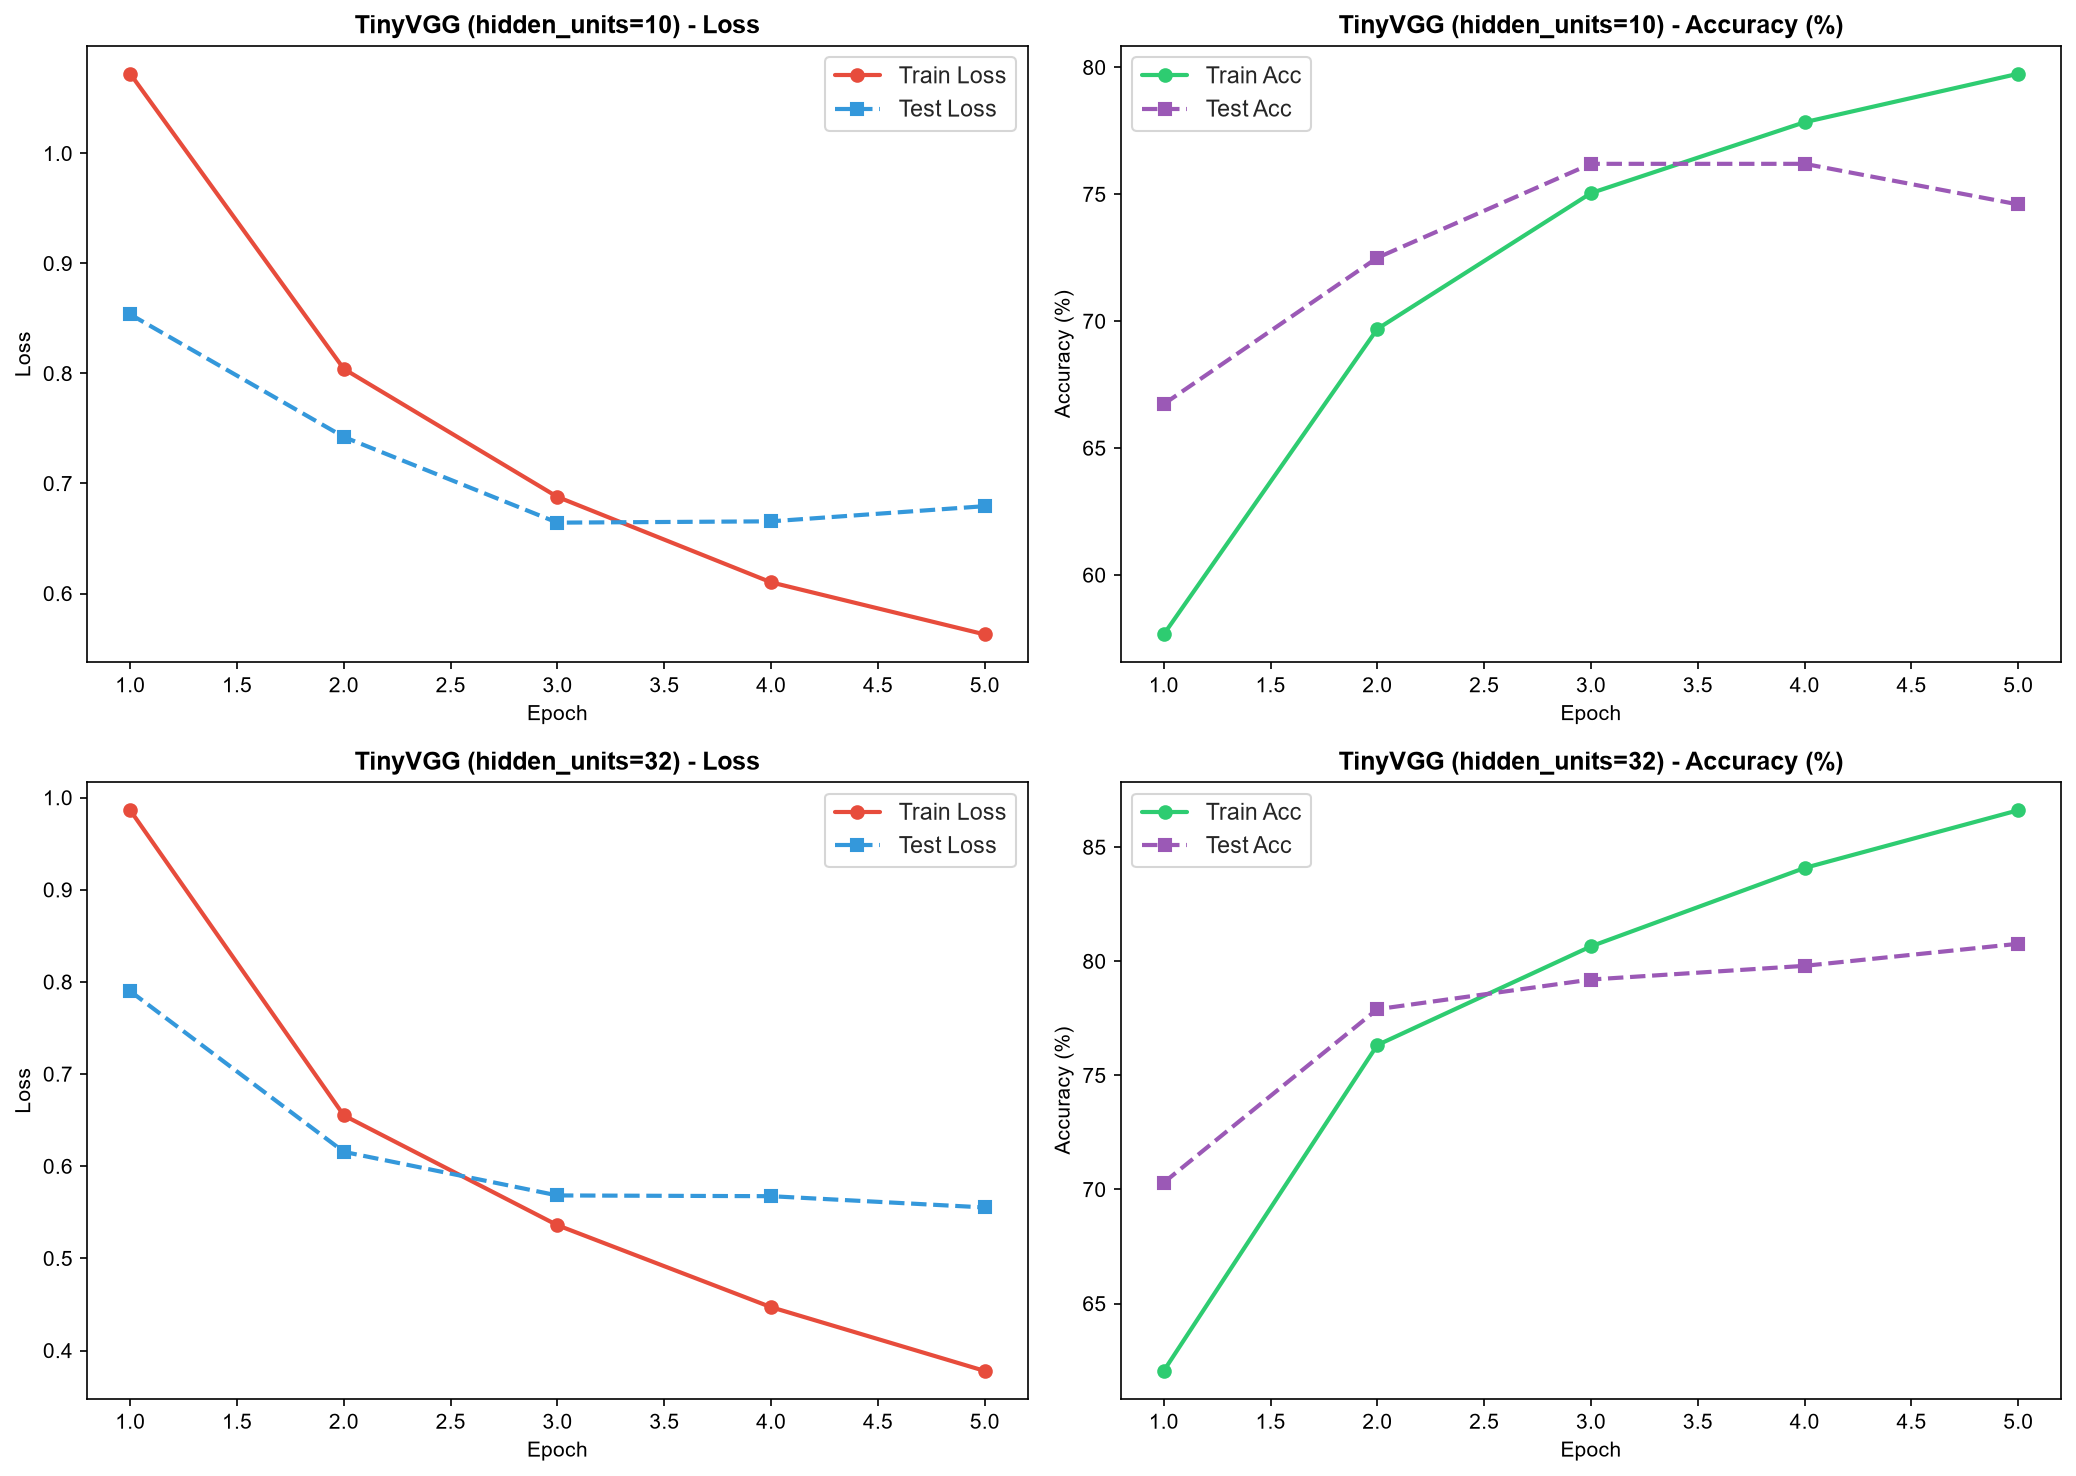

In [6]:
os.makedirs("../results", exist_ok=True)
os.makedirs("results", exist_ok=True)

epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=150)
sns.set_theme(style="whitegrid")

# Model 10 - Loss
axes[0, 0].plot(epochs_range, results_10["train_loss"], label="Train Loss", color="#e74c3c", marker='o', linewidth=2)
axes[0, 0].plot(epochs_range, results_10["test_loss"], label="Test Loss", color="#3498db", linestyle="--", marker='s', linewidth=2)
axes[0, 0].set_title("TinyVGG (hidden_units=10) - Loss", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()

# Model 10 - Accuracy
axes[0, 1].plot(epochs_range, [acc*100 for acc in results_10["train_acc"]], label="Train Acc", color="#2ecc71", marker='o', linewidth=2)
axes[0, 1].plot(epochs_range, [acc*100 for acc in results_10["test_acc"]], label="Test Acc", color="#9b59b6", linestyle="--", marker='s', linewidth=2)
axes[0, 1].set_title("TinyVGG (hidden_units=10) - Accuracy (%)", fontsize=12, fontweight="bold")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Accuracy (%)")
axes[0, 1].legend()

# Model 32 - Loss
axes[1, 0].plot(epochs_range, results_32["train_loss"], label="Train Loss", color="#e74c3c", marker='o', linewidth=2)
axes[1, 0].plot(epochs_range, results_32["test_loss"], label="Test Loss", color="#3498db", linestyle="--", marker='s', linewidth=2)
axes[1, 0].set_title("TinyVGG (hidden_units=32) - Loss", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Loss")
axes[1, 0].legend()

# Model 32 - Accuracy
axes[1, 1].plot(epochs_range, [acc*100 for acc in results_32["train_acc"]], label="Train Acc", color="#2ecc71", marker='o', linewidth=2)
axes[1, 1].plot(epochs_range, [acc*100 for acc in results_32["test_acc"]], label="Test Acc", color="#9b59b6", linestyle="--", marker='s', linewidth=2)
axes[1, 1].set_title("TinyVGG (hidden_units=32) - Accuracy (%)", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Accuracy (%)")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig("results/loss_accuracy_curves.png")
if os.path.exists("../results"):
    plt.savefig("../results/loss_accuracy_curves.png")
plt.show()


## 7. Confusion Matrix Analysis for Best Model

Best performing model: TinyVGG (hidden_units=32) with 80.77% test accuracy.


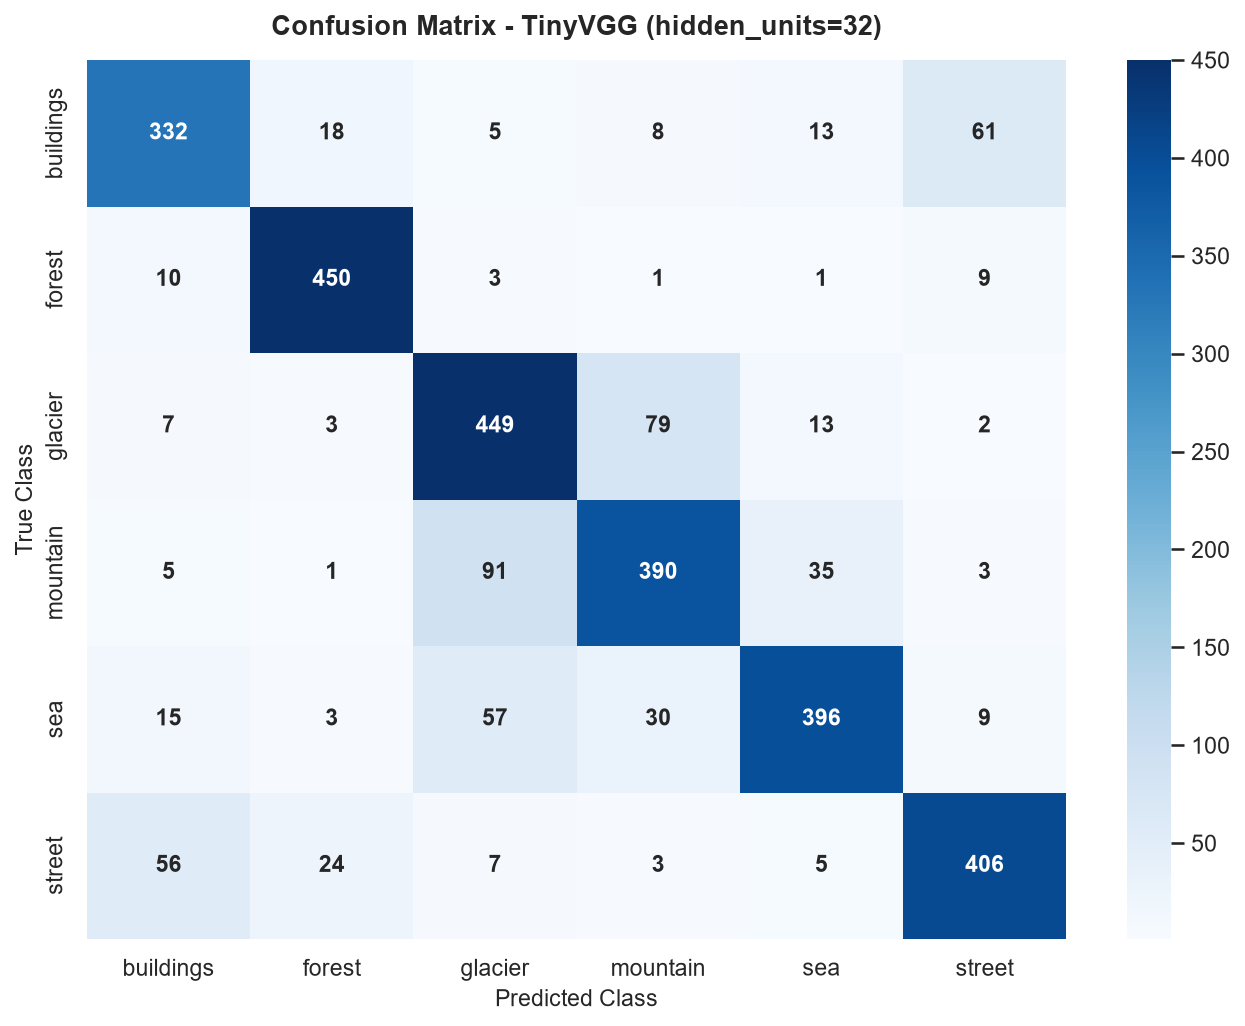

In [7]:
best_model = model_32 if max(results_32["test_acc"]) >= max(results_10["test_acc"]) else model_10
best_model_name = "TinyVGG (hidden_units=32)" if max(results_32["test_acc"]) >= max(results_10["test_acc"]) else "TinyVGG (hidden_units=10)"
best_accuracy = max(max(results_32["test_acc"]), max(results_10["test_acc"]))

print(f"Best performing model: {best_model_name} with {best_accuracy*100:.2f}% test accuracy.")

y_true = []
y_preds = []
best_model.eval()
with torch.inference_mode():
    for X, y in test_loader:
        X = X.to(device)
        logits = best_model(X)
        preds = torch.argmax(torch.softmax(logits, dim=1), dim=1)
        y_true.extend(y.cpu().numpy())
        y_preds.extend(preds.cpu().numpy())

cm = confusion_matrix(y_true, y_preds)
plt.figure(figsize=(9, 7), dpi=150)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 11, "weight": "bold"})
plt.xlabel("Predicted Class", fontsize=11)
plt.ylabel("True Class", fontsize=11)
plt.title(f"Confusion Matrix - {best_model_name}", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("results/confusion_matrix.png")
if os.path.exists("../results"):
    plt.savefig("../results/confusion_matrix.png")
plt.show()


## 8. Misclassified Example Visualization

Total misclassified test samples: 577 / 3000 (19.23% error rate)


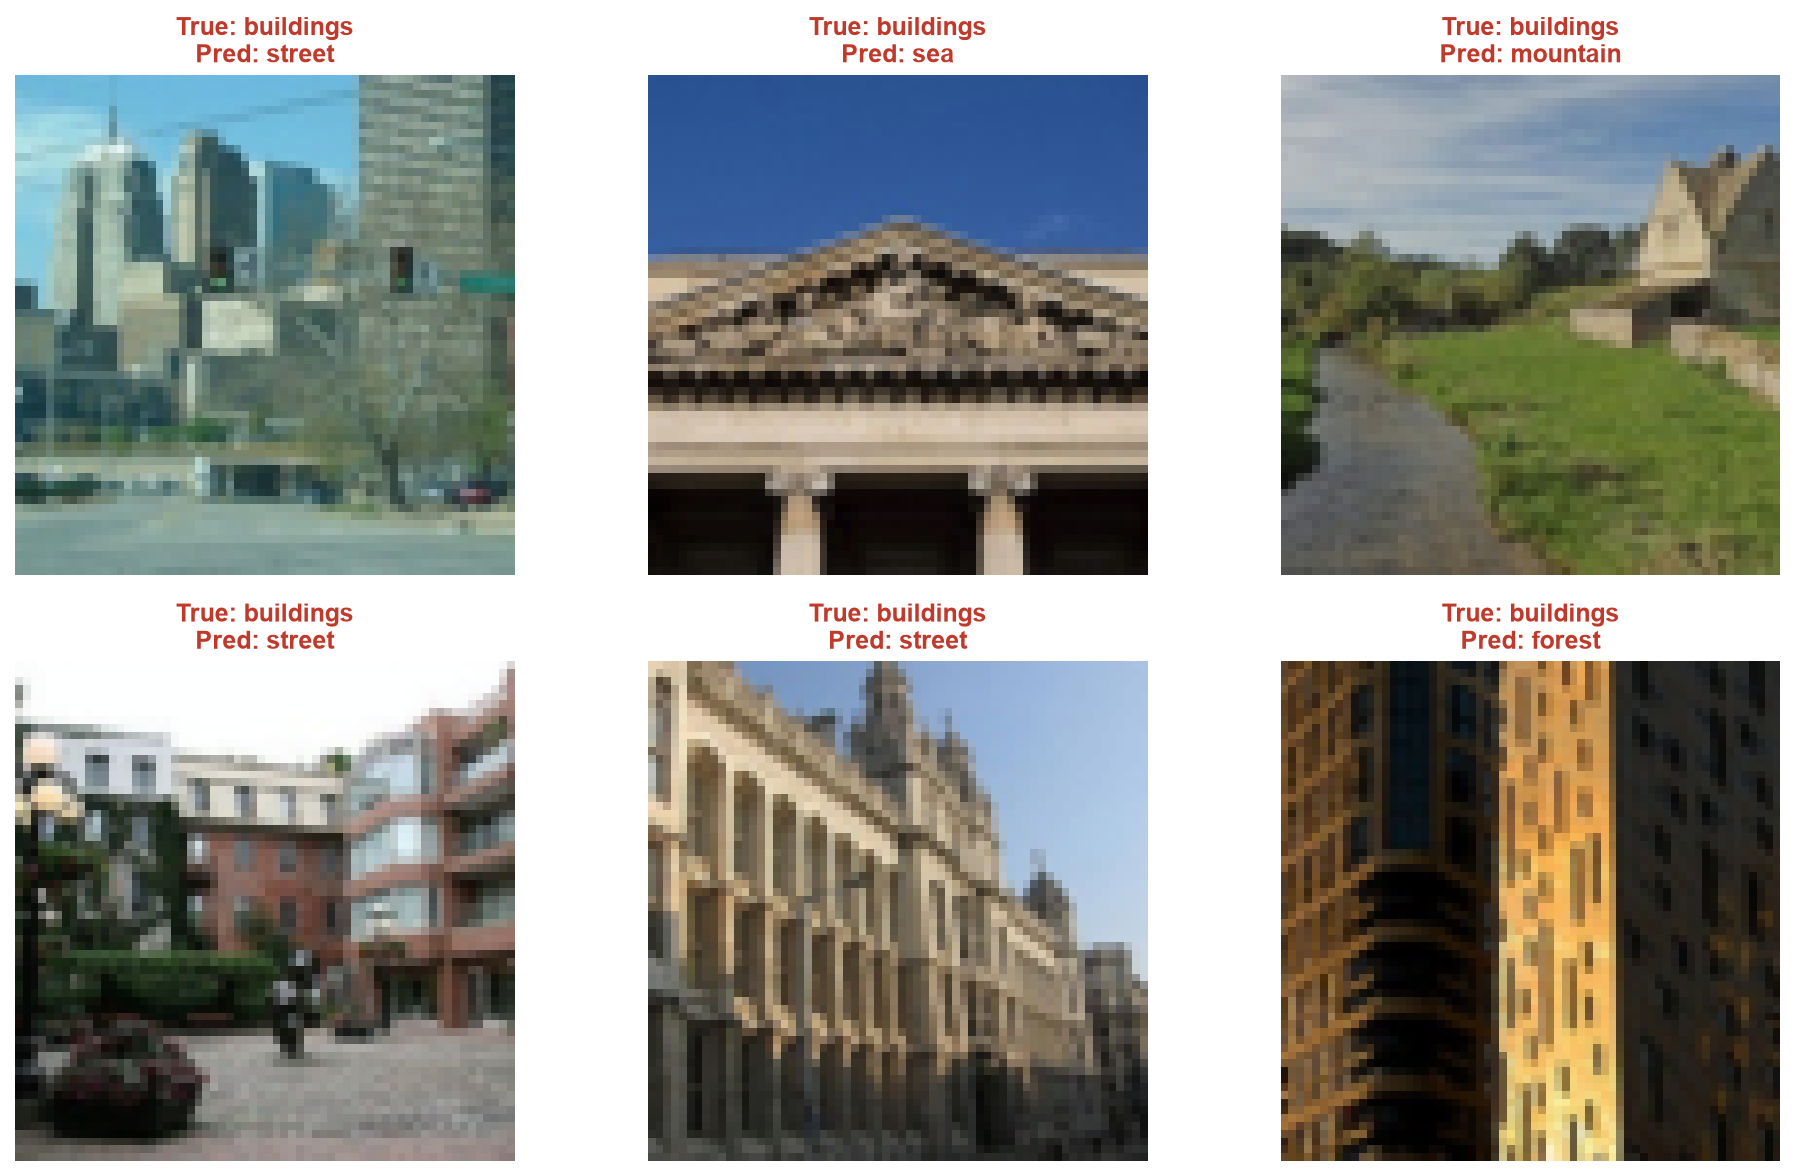

In [8]:
misclassified_idx = [i for i, (t, p) in enumerate(zip(y_true, y_preds)) if t != p]
print(f"Total misclassified test samples: {len(misclassified_idx)} / {len(test_data)} ({(len(misclassified_idx)/len(test_data))*100:.2f}% error rate)")

plt.figure(figsize=(13, 8), dpi=150)
for i, idx in enumerate(misclassified_idx[:6]):
    img, true_label = test_data[idx]
    pred_label = y_preds[idx]
    
    # Unnormalize image for RGB plotting
    img_np = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)
    
    plt.subplot(2, 3, i + 1)
    plt.imshow(img_np)
    plt.title(f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}", color="#c0392b", fontweight="bold")
    plt.axis("off")

plt.tight_layout()
plt.savefig("results/misclassified_examples.png")
if os.path.exists("../results"):
    plt.savefig("../results/misclassified_examples.png")
plt.show()


## 9. Checkpoint Best Model Weights (
esults/model.pth)

In [9]:
save_path = "results/model.pth"
torch.save(best_model.state_dict(), save_path)
if os.path.exists("../results"):
    torch.save(best_model.state_dict(), "../results/model.pth")
print(f"Saved best model weights to: {save_path}")


Saved best model weights to: results/model.pth
